project code


In [ ]:
import pandas as pd
from IPython.display import display

print('--- STEP 1: LOAD & UNDERSTAND THE DATA ---')

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"

print("Loading dataset...\n")
df = pd.read_csv(url)


print("--- 1. DATASET SHAPE ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}\n")

print("--- 2. DATASET INFO ---")
df.info()
print("\n")

print("--- 3. SUMMARY STATISTICS ---")

display(df.describe())


print("\n--- 4. COLUMN VERIFICATION ---")
print("Here are all the columns currently in the dataset:\n", df.columns.tolist(), "\n")

# verifying the specific columns needed for the project
expected_columns = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure',
    'TWF', 'HDF', 'PWF', 'OSF', 'RNF'
]

print("Checking for your target features and failure types:")
actual_columns = df.columns.tolist()
for col in expected_columns:
    if col in actual_columns:
        print(f"Found: '{col}'")
    else:
        print(f" Missing: '{col}' (Check for typos or formatting differences)")

--- STEP 1: LOAD & UNDERSTAND THE DATA ---
Loading dataset...

--- 1. DATASET SHAPE ---
Total Rows: 10000
Total Columns: 14

--- 2. DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-n

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000



--- 4. COLUMN VERIFICATION ---
Here are all the columns currently in the dataset:
 ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'] 

Checking for your target features and failure types:
Found: 'Air temperature [K]'
Found: 'Process temperature [K]'
Found: 'Rotational speed [rpm]'
Found: 'Torque [Nm]'
Found: 'Tool wear [min]'
Found: 'Machine failure'
Found: 'TWF'
Found: 'HDF'
Found: 'PWF'
Found: 'OSF'
Found: 'RNF'


In [ ]:
print('--- STEP 2: DATA CLEANING ---')

print('\nChecking for missing values:')
display(df.isnull().sum().to_frame(name='Missing Values'))

# Dropping irrelevant columns (UID and Product ID)
print('\nDropping UDI and Product ID columns...')
df = df.drop(columns=['UDI', 'Product ID'])
print('Columns after dropping:', df.columns.tolist())

print('\nVerifying data types after cleaning:')
df.info()

--- STEP 2: DATA CLEANING ---

Checking for missing values:


,Missing Values
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0



Dropping UDI and Product ID columns...
Columns after dropping: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Verifying data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
 7   TWF                      10000 non-null  int64  
 8   HDF                      10000 non-null  int64  
 9   PWF               

--- STEP 3: Exploratory Data Analysis   ---
Class Balance
Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


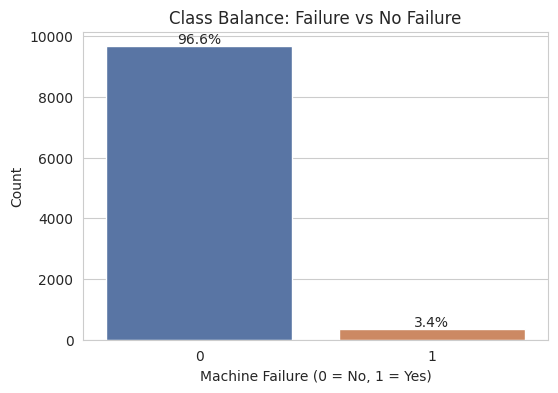

In [ ]:
print('--- STEP 3: Exploratory Data Analysis   ---')

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


#Class Balance - Machine Failure (0 = No Failure , 1 = Failure)
print("Class Balance")
failure_count = df["Machine failure"].value_counts()
failure_pct = df["Machine failure"].value_counts(normalize=True) * 100
print(failure_count)
print(failure_pct.round(2))

plt.figure(figsize=(6,4))
ax = sns.countplot(x='Machine failure' , hue='Machine failure', data = df , palette = ['#4C72B0','#DD8452'] ,  legend=False)
plt.title('Class Balance: Failure vs No Failure')
plt.xlabel('Machine Failure (0 = No, 1 = Yes)')
plt.ylabel('Count')

for p in ax.patches:
  pct = 100 * p.get_height() /len(df)
  ax.annotate(f'{pct:.1f}%' , (p.get_x() + p.get_width()/2 , p.get_height()) , ha = 'center' , va = "bottom")

plt.show()


The class distribution shows a significant imbalance in the dataset. Approximately 96.6% of the observations correspond to no machine failure (Class 0), while only 3.4% represent machine failure (Class 1). This indicates that machine failures are rare events, which is common in predictive maintenance datasets.

Such an imbalanced distribution may cause machine learning models to become biased toward predicting the majority class. Therefore, techniques such as SMOTE (Synthetic Minority Over-sampling Technique), class weighting, or resampling would be use to improve the model's ability to correctly identify failure cases.

Failure Type Breakdown
HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64


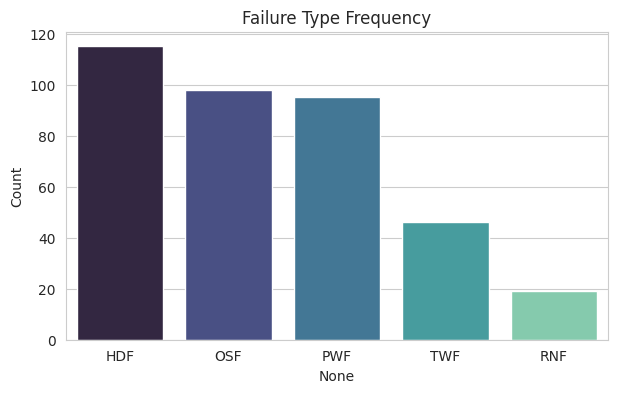

In [ ]:
#FAILURE TYPE BREAKDOWN (TWF, HDF, PWF, OSF, RNF)
print("Failure Type Breakdown")
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_type_counts = df[failure_types].sum().sort_values(ascending=False)
print(failure_type_counts)

plt.figure(figsize=(7,4))
sns.barplot(x=failure_type_counts.index , y = failure_type_counts.values ,hue=failure_type_counts.index , palette= 'mako' , legend=False)
plt.title('Failure Type Frequency')
plt.ylabel('Count')
plt.show()



Feature Distribution


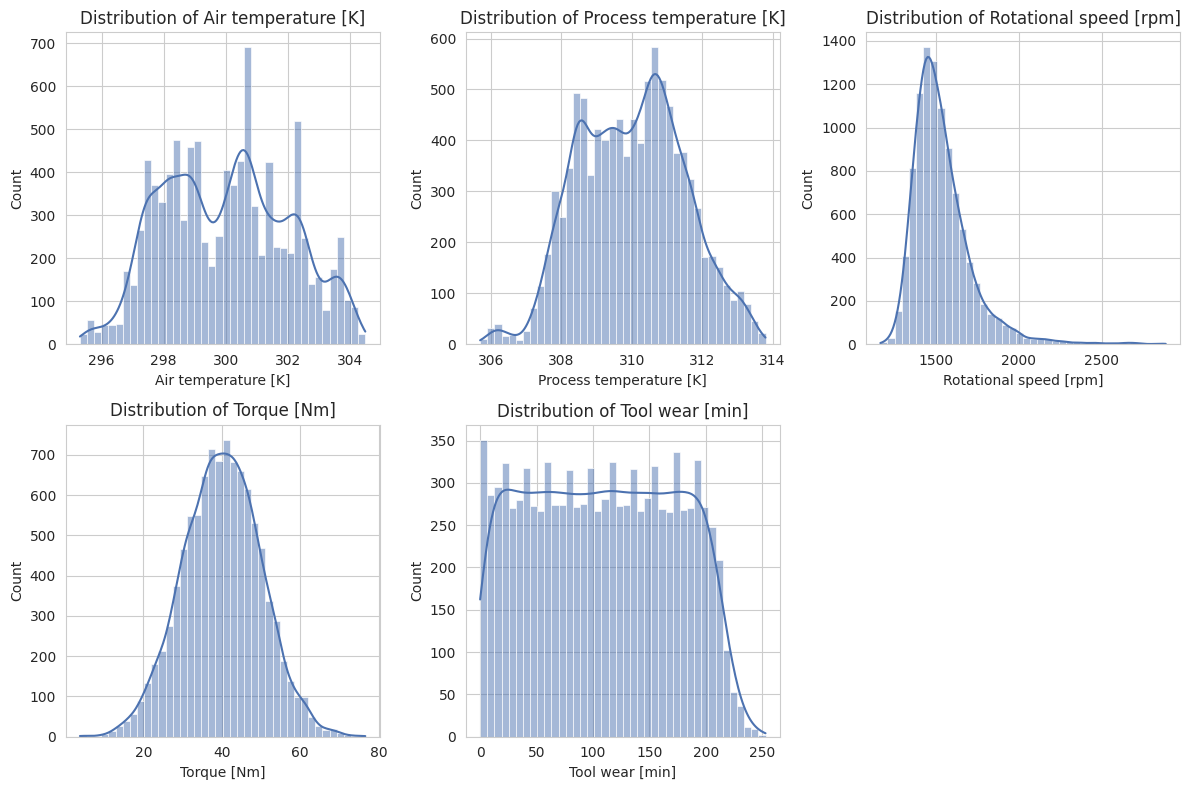

In [ ]:
# HISTOGRAMS — Torque, Temperatures, Speed, Tool wear

print("Feature Distribution")

numeric_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
fig , axes = plt.subplots(2,3,figsize=(12,8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
  sns.histplot(df[col] , kde= True , ax = axes[i] , color ='#4C72B0', bins=40)
  axes[i].set_title(f'Distribution of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

1. Air Temperature [K] :
The air temperature values range approximately from 295 K to 304 K.
The distribution is slightly multimodal, showing multiple small peaks instead of a single smooth peak, suggesting the data may have been collected under different operating conditions.
There are no significant outliers, and most observations lie between 298 K and 302 K.
2. Process Temperature [K]:
Process temperature ranges from approximately 306 K to 314 K.
The distribution is approximately bell-shaped (near normal) with a slight right skew.
Most observations are concentrated around 309–311 K, indicating a stable operating process.
3. Rotational Speed [rpm]:
The rotational speed distribution is positively (right) skewed.
Most machines operate between 1400 and 1600 rpm, while a small number operate at much higher speeds, creating a long right tail.
This indicates that high-speed operations are relatively rare.
4. Torque [Nm]:
Torque follows an approximately normal (Gaussian) distribution.
The highest concentration of values is around 40 Nm, with fewer observations at very low or very high torque values.
The distribution is fairly symmetric, suggesting consistent operating conditions.
5. Tool Wear [min]:
Tool wear is almost uniformly distributed between 0 and 200 minutes, meaning tools have been observed at nearly every wear level with similar frequency.
There is a sharp decline after 200 minutes, indicating very few tools exceed this wear limit.
This suggests the dataset intentionally includes tools across different stages of wear.



Feature Vs Failure


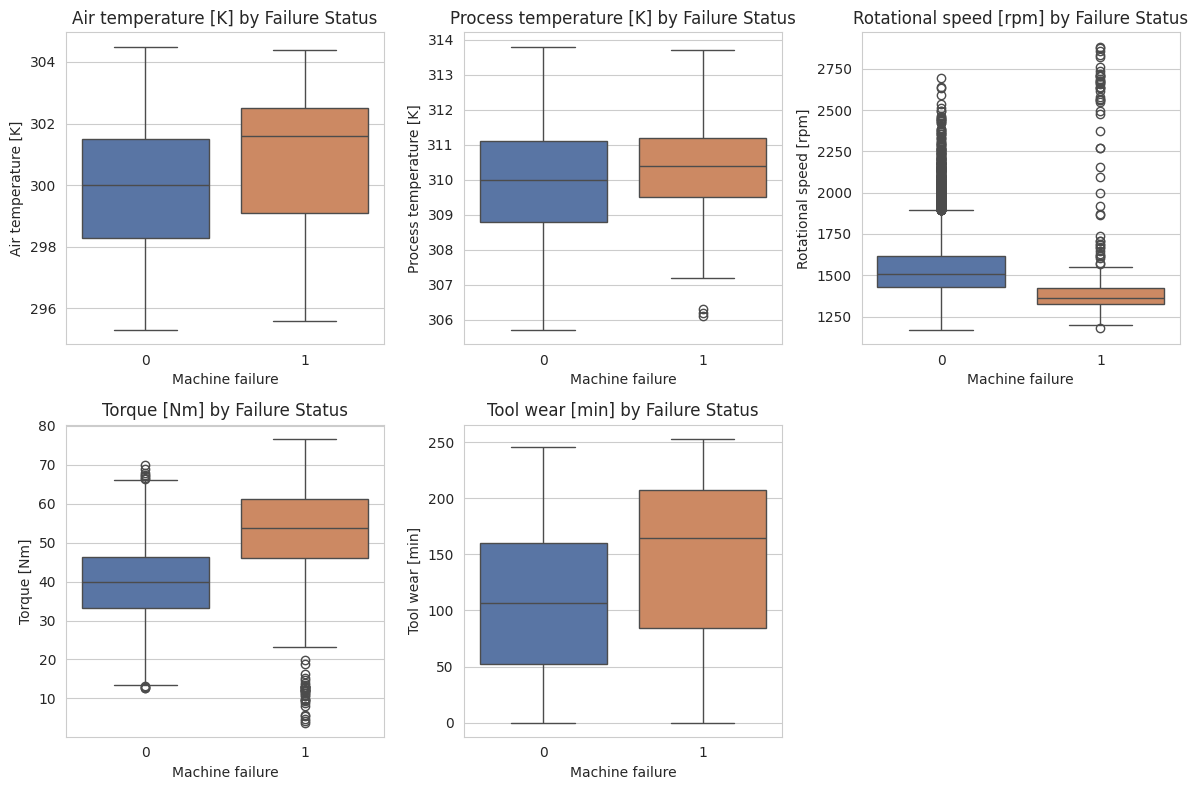

In [ ]:
#FEATURE DISTRIBUTIONS SPLIT BY FAILURE
print('Feature Vs Failure')
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i , col in enumerate(numeric_cols):
  sns.boxplot(x='Machine failure', y=col, data=df, hue ='Machine failure',  ax=axes[i], palette=['#4C72B0','#DD8452'] , legend=False)
  axes[i].set_title(f'{col} by Failure Status')
axes[-1].axis('off')
plt.tight_layout()
plt.show()


1. Air Temperature vs Machine Failure :
Machines that experienced failure generally have a slightly higher air temperature than those that did not fail.
However, there is considerable overlap between the two groups, suggesting that air temperature alone is not a strong predictor of machine failure.
2. Process Temperature vs Machine Failure :
Failed machines have a slightly higher median process temperature compared to non-failed machines.
The overlap between the two distributions is still substantial, indicating that process temperature has some influence but is not sufficient by itself to distinguish failures.
3. Rotational Speed vs Machine Failure :
Machines with failures tend to operate at a lower median rotational speed than non-failed machines.
Both groups contain several high-speed outliers, but the difference in median values suggests that rotational speed may be an important feature for predicting failures.
4. Torque vs Machine Failure :
Failed machines exhibit a significantly higher median torque than non-failed machines.
The two distributions are more clearly separated than for the temperature features, indicating that higher torque is strongly associated with machine failures.
Although a few outliers exist, torque appears to be one of the most informative predictors.
5. Tool Wear vs Machine Failure :
Machines that failed generally have higher tool wear than those that did not.
The median tool wear is noticeably greater for failed machines, suggesting that increased wear contributes to a higher likelihood of failure.
However, some overlap indicates that failures can also occur at lower wear levels.



Overall Interpretation

The boxplots indicate that torque, tool wear, and rotational speed show the most noticeable differences between failed and non-failed machines, making them potentially strong predictors for machine failure. In contrast, air temperature and process temperature exhibit only small shifts in their distributions, suggesting they have a weaker individual relationship with the target variable. These observations indicate that machine failure is likely influenced by a combination of multiple operating conditions rather than any single feature alone.

Correlation HeatMap
                         Air temperature [K]  Process temperature [K]  \
Air temperature [K]                     1.00                     0.88   
Process temperature [K]                 0.88                     1.00   
Rotational speed [rpm]                  0.02                     0.02   
Torque [Nm]                            -0.01                    -0.01   
Tool wear [min]                         0.01                     0.01   
Machine failure                         0.08                     0.04   
TWF                                     0.01                     0.01   
HDF                                     0.14                     0.06   
PWF                                     0.00                    -0.00   
OSF                                     0.00                     0.00   
RNF                                     0.02                     0.02   

                         Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  \
Air temperature [K]   

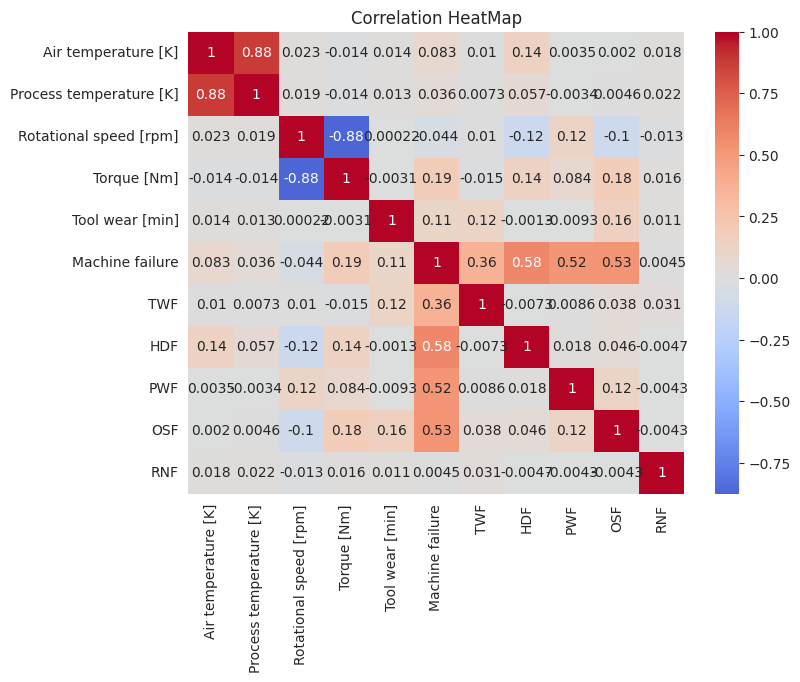

In [ ]:
# Correlation and HeatMap Graph
print("Correlation HeatMap")
corr_cols = numeric_cols + ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

corr_matrix = df[corr_cols].corr()
print(corr_matrix.round(2))

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix , annot=True , cmap = "coolwarm" , center=0)
plt.title('Correlation HeatMap')
plt.show()

Air temperature ↔ Process temperature::	0.8761 ::	Strong positive correlation
Rotational speed ↔ Torque	:: -0.8750	:: Strong negative correlation

Torque has the strongest positive correlation with machine failure, although the correlation is still relatively weak (0.191).
Tool wear also shows a weak positive relationship with failure (0.105).
Air temperature, process temperature, and rotational speed have very weak correlations with the target.

Machine failure ↔ HDF :: 0.58
Machine failure ↔ OSF :: 0.53
Machine failure ↔ PWF :: 0.52

Key Scatter Relationship


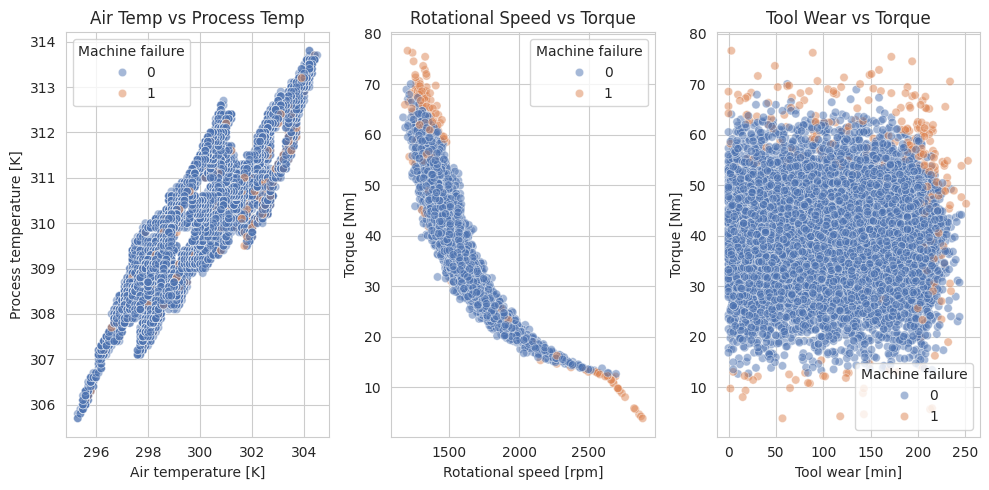

In [ ]:
#Key Relationships

print("Key Scatter Relationship")
fig , axes = plt.subplots(1,3 , figsize=(10,5))
sns.scatterplot(x='Air temperature [K]', y='Process temperature [K]', hue='Machine failure', data=df, alpha=0.5, ax=axes[0], palette=['#4C72B0','#DD8452'])
axes[0].set_title('Air Temp vs Process Temp')
sns.scatterplot(x='Rotational speed [rpm]', y='Torque [Nm]', hue='Machine failure', data=df, alpha=0.5, ax=axes[1], palette=['#4C72B0','#DD8452'])
axes[1].set_title('Rotational Speed vs Torque')
sns.scatterplot(x='Tool wear [min]', y='Torque [Nm]', hue='Machine failure', data=df, alpha=0.5, ax=axes[2], palette=['#4C72B0','#DD8452'])
axes[2].set_title('Tool Wear vs Torque')

plt.tight_layout()
plt.show()

1. Air Temperature vs Process Temperature :
The scatter plot shows a strong positive linear relationship between air temperature and process temperature.
2. Rotational Speed vs Torque :
There is a strong negative relationship between rotational speed and torque.
3. Tool Wear vs Torque :
The relationship between tool wear and torque is relatively weak, with no clear linear trend

Product Type Vs Failure Rate
Type
H    2.09
L    3.92
M    2.77
Name: Machine failure, dtype: float64


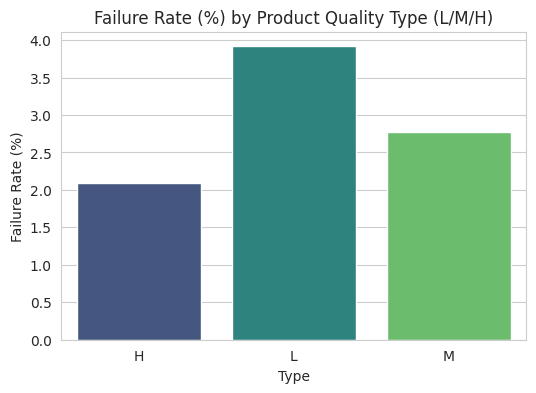

In [ ]:
print("Product Type Vs Failure Rate")
type_failure_rate = df.groupby('Type')['Machine failure'].mean() *100
print(type_failure_rate.round(2))

plt.figure(figsize=(6,4))
sns.barplot(x=type_failure_rate.index , y=type_failure_rate.values ,hue = type_failure_rate.index ,  palette = "viridis" , legend=False)
plt.title('Failure Rate (%) by Product Quality Type (L/M/H)')
plt.ylabel('Failure Rate (%)')
plt.show()

In [ ]:
print('--- STEP 4: PREPARE FEATURES & TARGET ---')

# 1. Encode the Categorical Column ('Type')
# We'll use pandas get_dummies for one-hot encoding.
# drop_first=True prevents the "dummy variable trap" by dropping one of the categories.
# dtype=int ensures the output is 0 and 1 instead of True and False.
print("\nEncoding the 'Type' column (L, M, H)...")
df_encoded = pd.get_dummies(df, columns=['Type'], drop_first=True, dtype=int)
print("Columns after one-hot encoding:\n", df_encoded.columns.tolist())

# 2. Define the Targets (y)
print("\nSeparating targets from features...")
# Binary target for initial modeling
y_binary = df_encoded['Machine failure']

# Multiclass/Multi-label targets for later experimentation
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
y_multi = df_encoded[failure_types]

# 3. Define the Features (X)

columns_to_drop = ['Machine failure'] + failure_types
X = df_encoded.drop(columns=columns_to_drop)

# 4. Verify the Splits
print('\n--- Feature Set (X) ---')
display(X.head())
print(f"Shape of X: {X.shape}")

print('\n--- Binary Target (y_binary) ---')
display(y_binary.head().to_frame())
print(f"Shape of y_binary: {y_binary.shape}")

print('\n--- Failure Type Targets (y_multi) ---')
display(y_multi.head())
print(f"Shape of y_multi: {y_multi.shape}")

--- STEP 4: PREPARE FEATURES & TARGET ---

Encoding the 'Type' column (L, M, H)...
Columns after one-hot encoding:
 ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_L', 'Type_M']

Separating targets from features...

--- Feature Set (X) ---


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,1
1,298.2,308.7,1408,46.3,3,1,0
2,298.1,308.5,1498,49.4,5,1,0
3,298.2,308.6,1433,39.5,7,1,0
4,298.2,308.7,1408,40.0,9,1,0


Shape of X: (10000, 7)

--- Binary Target (y_binary) ---


,Machine failure
0,0
1,0
2,0
3,0
4,0


Shape of y_binary: (10000,)

--- Failure Type Targets (y_multi) ---


,TWF,HDF,PWF,OSF,RNF
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


Shape of y_multi: (10000, 5)


In [ ]:
print('--- STEP 5: SPLIT THE DATA ---')

from sklearn.model_selection import train_test_split

# Splitting into training and testing sets (80% train, 20% test) for binary y
print("Splitting data into training and testing sets (80/20 split) with stratification...")
X_bi_train, X_bi_test, y_bi_train, y_bi_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)


# Verifying the shapes of the split datasets
print(f"\nShape of X_train: {X_bi_train.shape}")
print(f"Shape of y_train: {y_bi_train.shape}")
print(f"Shape of X_test: {X_bi_test.shape}")
print(f"Shape of y_test: {y_bi_test.shape}")


print("\nClass distribution in y_train:")
print(y_bi_train.value_counts(normalize=True).round(4))
print("\nClass distribution in y_test:")
print(y_bi_test.value_counts(normalize=True).round(4))

--- STEP 5: SPLIT THE DATA ---
Splitting data into training and testing sets (80/20 split) with stratification...

Shape of X_train: (8000, 7)
Shape of y_train: (8000,)
Shape of X_test: (2000, 7)
Shape of y_test: (2000,)

Class distribution in y_train:
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

Class distribution in y_test:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


In [ ]:
#Step 5b , Spilting for y_multi
print('STEP 5b: ALIGN y_multi TO THE SAME SPLIT')

y_multi_train = y_multi.loc[X_bi_train.index]
y_multi_test = y_multi.loc[X_bi_test.index]

assert (X_bi_train.index == y_multi_train.index).all()
assert (X_bi_test.index == y_multi_test.index).all()
print("y_multi aligned to Stage 1 split.")
print(f"y_multi_train shape: {y_multi_train.shape}")
print(f"y_multi_test shape: {y_multi_test.shape}")

STEP 5b: ALIGN y_multi TO THE SAME SPLIT
y_multi aligned to Stage 1 split.
y_multi_train shape: (8000, 5)
y_multi_test shape: (2000, 5)


In [ ]:
#Step 6a - SMOTE for Stage 1 (binary) , partial oversampling
from imblearn.over_sampling import SMOTE

# Check imbalance before
print("Before SMOTE — class distribution in y_bi_train:")
print(y_bi_train.value_counts())

#Applying SMOTE on training data
# Partial oversampling: minority class becomes 50% of majority class size
smote = SMOTE(random_state=42 , sampling_strategy=0.5)
X_bi_train_smote ,y_bi_train_smote = smote.fit_resample(X_bi_train , y_bi_train)
print("\nAfter SMOTE — class distribution in y_bi_train_smote:")
print(y_bi_train_smote.value_counts())
print(f"\nShape of X_bi_train_smote: {X_bi_train_smote.shape}")
print(f"Shape of y_bi_train_smote: {y_bi_train_smote.shape}")

Before SMOTE — class distribution in y_bi_train:
Machine failure
0    7729
1     271
Name: count, dtype: int64

After SMOTE — class distribution in y_bi_train_smote:
Machine failure
0    7729
1    3864
Name: count, dtype: int64

Shape of X_bi_train_smote: (11593, 7)
Shape of y_bi_train_smote: (11593,)


In [ ]:
#FEATURE SCALING
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_bi_train_scaled = scaler.fit_transform(X_bi_train_smote)

scaler = StandardScaler()

X_bi_train_scaled = scaler.fit_transform(X_bi_train_smote)
X_bi_test_scaled = scaler.transform(X_bi_test)

print(f"X_bi_train_scaled shape: {X_bi_train_scaled.shape}")
print(f"X_bi_test_scaled shape: {X_bi_test_scaled.shape}")

X_bi_train_scaled shape: (11593, 7)
X_bi_test_scaled shape: (2000, 7)


In [ ]:
#Data Prep for Stage 2 , y_multi , using the failure rows only from original dataset
#keeping only the rows with machine failure

# Filter using ORIGINAL (non-SMOTE) X_bi_train/y_bi_train — real failures only
failure_mask_train = y_bi_train == 1
X_stage2_train = X_bi_train[failure_mask_train]
y_multi_train_stage2 = y_multi_train[failure_mask_train]

failure_mask_test = y_bi_test == 1
X_stage2_test = X_bi_test[failure_mask_test]
y_multi_test_stage2 = y_multi_test[failure_mask_test]

In [ ]:
#Apply the SAME fitted scaler
X_stage2_train_scaled = scaler.transform(X_stage2_train)
X_stage2_test_scaled = scaler.transform(X_stage2_test)
print(f"\nX_stage2_train_scaled shape: {X_stage2_train_scaled.shape}")
print(f"X_stage2_test_scaled shape: {X_stage2_test_scaled.shape}")


X_stage2_train_scaled shape: (271, 7)
X_stage2_test_scaled shape: (68, 7)


In [ ]:
#to check whether stage 2 data need SMOTE or not
print(y_multi_train_stage2.sum())
print(y_multi_test_stage2['RNF'].sum())

TWF    36
HDF    86
PWF    82
OSF    82
RNF     1
dtype: int64
0


In [ ]:
print('--- STEP 7: TRAIN THE MODEL and compare ---')


from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd



--- STEP 7: TRAIN THE MODEL and compare ---


In [ ]:
print('--- STEP 7: DETAILED COMPREHENSIVE K-FOLD CROSS-VALIDATION MATRIX ---')

import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Import our 4 classifiers
import xgboost as xgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the 4 Models
models = {
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# 2. Set up Stratified 5-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to hold all structural fold data for our final formatted matrix DataFrame
matrix_data = {}

# 3. Manually loop through each model and each fold
for model_name, model_object in models.items():
    print(f"\n==================================================================")
    print(f" Evaluating Model: {model_name} across 5 Folds")
    print(f"==================================================================")

    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []

    for fold_num, (train_index, val_index) in enumerate(skf.split(X_bi_train_scaled, y_bi_train_smote), 1):

        # Isolate this specific fold's training and validation slices
        X_fold_train, X_fold_val = X_bi_train_scaled[train_index], X_bi_train_scaled[val_index]
        y_fold_train, y_fold_val = y_bi_train_smote.iloc[train_index], y_bi_train_smote.iloc[val_index]

        # Clone the model architecture so it starts completely fresh for this fold
        fresh_model = clone(model_object)

        # Train on the 4 training folds
        fresh_model.fit(X_fold_train, y_fold_train)

        # Test on the 1 holdout validation fold
        predictions = fresh_model.predict(X_fold_val)

        # Calculate all 4 requested core metrics
        acc = accuracy_score(y_fold_val, predictions)
        prec = precision_score(y_fold_val, predictions, zero_division=0)
        rec = recall_score(y_fold_val, predictions, zero_division=0)
        f1 = f1_score(y_fold_val, predictions, zero_division=0)

        # Append scores to lists
        fold_accuracies.append(acc)
        fold_precisions.append(prec)
        fold_recalls.append(rec)
        fold_f1s.append(f1)

        print(f" -> Fold #{fold_num} | Acc: {acc*100:.1f}% | Prec: {prec*100:.1f}% | Rec: {rec*100:.1f}% | F1: {f1*100:.1f}%")

    # Save lists into our matrix tracker data dictionary using a multi-index key structure
    matrix_data[(model_name, 'Accuracy')] = fold_accuracies
    matrix_data[(model_name, 'Precision')] = fold_precisions
    matrix_data[(model_name, 'Recall')] = fold_recalls
    matrix_data[(model_name, 'F1-Score')] = fold_f1s

    # Print clean console summary for this specific model
    print(f"\n Summary for {model_name}:")
    print(f"   Average CV Accuracy : {np.mean(fold_accuracies) * 100:.2f}% (+/- {np.std(fold_accuracies) * 100:.2f}%)")
    print(f"   Average CV F1-Score : {np.mean(fold_f1s) * 100:.2f}% (+/- {np.std(fold_f1s) * 100:.2f}%)")

# 4. Construct a structured, multi-indexed academic matrix table
print("\n\n--- COMPLETE ACADEMIC CROSS-VALIDATION MATRIX ---")
# Convert dictionary to DataFrame and transpose so models are on rows
matrix_df = pd.DataFrame(matrix_data).T
matrix_df.columns = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']

# Assign descriptive names to our MultiIndex levels
matrix_df.index.names = ['Model', 'Metric']

# Calculate the mean and standard deviation across columns (axis=1) for all 4 metrics
matrix_df['Mean CV Score'] = matrix_df.mean(axis=1)
matrix_df['Standard Deviation'] = matrix_df.std(axis=1)

# Format the entire structured table as percentages for presentation
display(matrix_df.style.format(lambda x: f"{x*100:.2f}%"))

--- STEP 7: DETAILED COMPREHENSIVE K-FOLD CROSS-VALIDATION MATRIX ---

 Evaluating Model: XGBoost across 5 Folds
 -> Fold #1 | Acc: 98.1% | Prec: 96.3% | Rec: 98.2% | F1: 97.2%
 -> Fold #2 | Acc: 97.8% | Prec: 96.1% | Rec: 97.5% | F1: 96.8%
 -> Fold #3 | Acc: 98.4% | Prec: 96.8% | Rec: 98.4% | F1: 97.6%
 -> Fold #4 | Acc: 98.5% | Prec: 97.9% | Rec: 97.5% | F1: 97.7%
 -> Fold #5 | Acc: 98.1% | Prec: 96.5% | Rec: 97.7% | F1: 97.1%

 Summary for XGBoost:
   Average CV Accuracy : 98.19% (+/- 0.23%)
   Average CV F1-Score : 97.30% (+/- 0.34%)

 Evaluating Model: KNN across 5 Folds
 -> Fold #1 | Acc: 95.7% | Prec: 90.0% | Rec: 97.9% | F1: 93.8%
 -> Fold #2 | Acc: 94.3% | Prec: 88.1% | Rec: 95.9% | F1: 91.8%
 -> Fold #3 | Acc: 95.0% | Prec: 89.3% | Rec: 96.4% | F1: 92.7%
 -> Fold #4 | Acc: 96.0% | Prec: 91.3% | Rec: 97.4% | F1: 94.2%
 -> Fold #5 | Acc: 95.7% | Prec: 91.2% | Rec: 96.5% | F1: 93.8%

 Summary for KNN:
   Average CV Accuracy : 95.34% (+/- 0.63%)
   Average CV F1-Score : 93.27% (+

In [ ]:
#step 7 but here we are predicting what kind of error occurs in case of failiure
print("Initializing Multi-Output Classifiers for maintenance type prediction...")
from sklearn.multioutput import MultiOutputClassifier
stage2_models = {
    "XGBoost": MultiOutputClassifier(xgb.XGBClassifier(random_state=42, eval_metric='logloss')),
    "KNN": MultiOutputClassifier(KNeighborsClassifier(n_neighbors=3)),
    "Logistic Regression": MultiOutputClassifier(LogisticRegression(random_state=42, max_iter=1000)),
    "Random Forest": MultiOutputClassifier(RandomForestClassifier(random_state=42))
}

stage2_results = []
failure_type_names = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']


for name, model in stage2_models.items():
    print(f"\nTraining {name} on breakdown historical data...")

    # Train using ONLY the rows where a machine actually failed
    model.fit(X_stage2_train_scaled, y_multi_train_stage2)

    # Predict failure types on the test set failures
    y_pred_stage2 = model.predict(X_stage2_test_scaled)

    # Calculate Exact Match Accuracy (Subset Accuracy)
    # This means the model must get ALL 5 failure types right for a row to count as correct
    exact_match_acc = accuracy_score(y_multi_test_stage2, y_pred_stage2)

    stage2_results.append({
        "Model": name,
        "Exact Match Accuracy": f"{exact_match_acc * 100:.2f}%"
    })

    print(f"\n--- Detailed Classification Report for {name} ---")
    print(classification_report(y_multi_test_stage2, y_pred_stage2, target_names=failure_type_names, zero_division=0))

print("\n=== STAGE 2: MAINTENANCE TYPE PREDICTION COMPARISON ===")
stage2_df = pd.DataFrame(stage2_results)
display(stage2_df)

Initializing Multi-Output Classifiers for maintenance type prediction...

Training XGBoost on breakdown historical data...

--- Detailed Classification Report for XGBoost ---
              precision    recall  f1-score   support

         TWF       0.71      0.50      0.59        10
         HDF       0.96      0.90      0.93        29
         PWF       0.87      1.00      0.93        13
         OSF       0.84      1.00      0.91        16
         RNF       0.00      0.00      0.00         0

   micro avg       0.88      0.88      0.88        68
   macro avg       0.68      0.68      0.67        68
weighted avg       0.88      0.88      0.88        68
 samples avg       0.82      0.86      0.83        68


Training KNN on breakdown historical data...

--- Detailed Classification Report for KNN ---
              precision    recall  f1-score   support

         TWF       0.78      0.70      0.74        10
         HDF       0.96      0.90      0.93        29
         PWF       0.80  

,Model,Exact Match Accuracy
0,XGBoost,77.94%
1,KNN,82.35%
2,Logistic Regression,86.76%
3,Random Forest,85.29%


In [ ]:
print('--- STEP 7b: REBALANCING ABLATION (XGBoost, Stage 1) ---')

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# We work from the ORIGINAL unscaled, un-SMOTEd training data
# (X_bi_train, y_bi_train) so each method controls rebalancing itself, per fold.
X_raw = X_bi_train.reset_index(drop=True)
y_raw = y_bi_train.reset_index(drop=True)

ablation_results = {}

def run_cv(method_name, fit_fn):
    """fit_fn(X_train_fold, y_train_fold) -> fitted model, trained however the method needs"""
    accs, precs, recs, f1s, aucs = [], [], [], [], []

    for fold_num, (train_idx, val_idx) in enumerate(skf.split(X_raw, y_raw), 1):
        X_tr, X_val = X_raw.iloc[train_idx], X_raw.iloc[val_idx]
        y_tr, y_val = y_raw.iloc[train_idx], y_raw.iloc[val_idx]

        # Scale using only this fold's training data (no leakage)
        scaler_fold = StandardScaler()
        X_tr_scaled = scaler_fold.fit_transform(X_tr)
        X_val_scaled = scaler_fold.transform(X_val)

        model = fit_fn(X_tr_scaled, y_tr)

        preds = model.predict(X_val_scaled)
        probs = model.predict_proba(X_val_scaled)[:, 1]

        accs.append(accuracy_score(y_val, preds))
        precs.append(precision_score(y_val, preds, zero_division=0))
        recs.append(recall_score(y_val, preds, zero_division=0))
        f1s.append(f1_score(y_val, preds, zero_division=0))
        aucs.append(roc_auc_score(y_val, probs))

        print(f" -> Fold #{fold_num} | Acc: {accs[-1]*100:.1f}% | Prec: {precs[-1]*100:.1f}% | "
              f"Rec: {recs[-1]*100:.1f}% | F1: {f1s[-1]*100:.1f}% | AUC: {aucs[-1]:.3f}")

    ablation_results[method_name] = {
        'Accuracy': np.mean(accs), 'Precision': np.mean(precs),
        'Recall': np.mean(recs), 'F1-Score': np.mean(f1s), 'AUC': np.mean(aucs),
        'F1 Std': np.std(f1s)
    }
    print(f"\n Mean F1 for {method_name}: {np.mean(f1s)*100:.2f}% (+/- {np.std(f1s)*100:.2f}%)\n")


# (a) No rebalancing — raw class distribution, no correction at all
print("\n=== (a) No Rebalancing ===")
def fit_none(X_tr, y_tr):
    m = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    m.fit(X_tr, y_tr)
    return m
run_cv("No Rebalancing", fit_none)


# (b) SMOTE — synthetic minority oversampling, applied fresh inside this fold only
print("\n=== (b) SMOTE (sampling_strategy=0.5) ===")
def fit_smote(X_tr, y_tr):
    sm = SMOTE(random_state=42, sampling_strategy=0.5)
    X_res, y_res = sm.fit_resample(X_tr, y_tr)
    m = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    m.fit(X_res, y_res)
    return m
run_cv("SMOTE", fit_smote)


# (c) scale_pos_weight — no synthetic data, just reweight the loss function
print("\n=== (c) scale_pos_weight only ===")
def fit_spw(X_tr, y_tr):
    neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    spw = neg / pos
    m = xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=spw)
    m.fit(X_tr, y_tr)
    return m
run_cv("scale_pos_weight", fit_spw)


# Final comparison table
print("\n\n--- ABLATION SUMMARY: REBALANCING STRATEGY COMPARISON ---")
ablation_df = pd.DataFrame(ablation_results).T
display(ablation_df.style.format({
    'Accuracy': '{:.2%}', 'Precision': '{:.2%}', 'Recall': '{:.2%}',
    'F1-Score': '{:.2%}', 'AUC': '{:.3f}', 'F1 Std': '{:.4f}'
}))

--- STEP 7b: REBALANCING ABLATION (XGBoost, Stage 1) ---

=== (a) No Rebalancing ===
 -> Fold #1 | Acc: 98.4% | Prec: 83.3% | Rec: 64.8% | F1: 72.9% | AUC: 0.987
 -> Fold #2 | Acc: 98.4% | Prec: 80.4% | Rec: 68.5% | F1: 74.0% | AUC: 0.977
 -> Fold #3 | Acc: 98.1% | Prec: 73.1% | Rec: 70.4% | F1: 71.7% | AUC: 0.959
 -> Fold #4 | Acc: 98.4% | Prec: 85.0% | Rec: 63.0% | F1: 72.3% | AUC: 0.966
 -> Fold #5 | Acc: 98.1% | Prec: 85.7% | Rec: 54.5% | F1: 66.7% | AUC: 0.943

 Mean F1 for No Rebalancing: 71.52% (+/- 2.54%)


=== (b) SMOTE (sampling_strategy=0.5) ===
 -> Fold #1 | Acc: 97.7% | Prec: 62.0% | Rec: 81.5% | F1: 70.4% | AUC: 0.986
 -> Fold #2 | Acc: 97.6% | Prec: 62.1% | Rec: 75.9% | F1: 68.3% | AUC: 0.969
 -> Fold #3 | Acc: 97.3% | Prec: 57.7% | Rec: 75.9% | F1: 65.6% | AUC: 0.962
 -> Fold #4 | Acc: 97.9% | Prec: 66.2% | Rec: 79.6% | F1: 72.3% | AUC: 0.980
 -> Fold #5 | Acc: 97.9% | Prec: 66.7% | Rec: 76.4% | F1: 71.2% | AUC: 0.970

 Mean F1 for SMOTE: 69.56% (+/- 2.36%)


=== (c) sc

,Accuracy,Precision,Recall,F1-Score,AUC,F1 Std
No Rebalancing,98.28%,81.51%,64.24%,71.52%,0.966,0.0254
SMOTE,97.69%,62.93%,77.87%,69.56%,0.973,0.0236
scale_pos_weight,98.17%,73.37%,72.71%,72.99%,0.970,0.0535


In [ ]:
print('--- STEP 8: HYPERPARAMETER TUNING ---')
from sklearn.model_selection import GridSearchCV
# 1) Hypertune binary XGBoost — using scale_pos_weight, NOT SMOTE
print('\n--- 1. Hyperparameter Tuning for XGBoost (Binary Classification) ---')

# Need a fresh scaler + scaled data WITHOUT SMOTE (original imbalanced training set)
scaler_final = StandardScaler()
X_bi_train_scaled_noSMOTE = scaler_final.fit_transform(X_bi_train)
X_bi_test_scaled_noSMOTE = scaler_final.transform(X_bi_test)

# Compute the base class ratio to center the scale_pos_weight search around
neg, pos = (y_bi_train == 0).sum(), (y_bi_train == 1).sum()
base_spw = neg / pos
print(f"Base scale_pos_weight (neg/pos ratio): {base_spw:.2f}")

binary_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'scale_pos_weight': [1, base_spw * 0.5, base_spw, base_spw * 1.5]  # let CV pick the best weight
}

grid_search_xgb_binary = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=binary_param_grid,
    scoring='f1',
    cv=5,  # bumped to 5 now that we're not relying on SMOTE-inflated folds
    verbose=1,
    n_jobs=-1
)

print("Fitting GridSearchCV for XGBoost (binary)...")
grid_search_xgb_binary.fit(X_bi_train_scaled_noSMOTE, y_bi_train)  # <-- real data, no SMOTE

print("\nBest parameters for XGBoost (binary):", grid_search_xgb_binary.best_params_)
print("Best F1-score for XGBoost (binary) during CV:", grid_search_xgb_binary.best_score_)

best_xgb_binary_model = grid_search_xgb_binary.best_estimator_
y_pred_xgb_binary = best_xgb_binary_model.predict(X_bi_test_scaled_noSMOTE)

print("\n--- Classification Report for Tuned XGBoost (Binary) on Test Set ---")
print(classification_report(y_bi_test, y_pred_xgb_binary, zero_division=0))


# 2) Hypertune multi for Logistic Regression model — unchanged, no SMOTE was ever used here
print('\n--- 2. Hyperparameter Tuning for Logistic Regression (Multi-Output) ---')

multi_lr_param_grid = {
    'estimator__C': [0.01, 0.1, 1, 10],
    'estimator__penalty': ['l2'],
    'estimator__solver': ['liblinear']
}

grid_search_multi_lr = GridSearchCV(
    estimator=MultiOutputClassifier(LogisticRegression(random_state=42, max_iter=1000)),
    param_grid=multi_lr_param_grid,
    scoring='f1_micro',
    cv=3,
    verbose=1,
    n_jobs=-1
)

print("Fitting GridSearchCV for Multi-Output Logistic Regression...")
grid_search_multi_lr.fit(X_stage2_train_scaled, y_multi_train_stage2)

print("\nBest parameters for Multi-Output Logistic Regression:", grid_search_multi_lr.best_params_)
print("Best F1-micro score for Multi-Output Logistic Regression during CV:", grid_search_multi_lr.best_score_)

best_multi_lr_model = grid_search_multi_lr.best_estimator_
y_pred_multi_lr = best_multi_lr_model.predict(X_stage2_test_scaled)

print("\n--- Classification Report for Tuned Multi-Output Logistic Regression on Test Set ---")
failure_type_names = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print(classification_report(y_multi_test_stage2, y_pred_multi_lr, target_names=failure_type_names, zero_division=0))

exact_match_acc_tuned_lr = accuracy_score(y_multi_test_stage2, y_pred_multi_lr)
print(f"\nExact Match Accuracy for Tuned Multi-Output Logistic Regression: {exact_match_acc_tuned_lr * 100:.2f}%")

--- STEP 8: HYPERPARAMETER TUNING ---

--- 1. Hyperparameter Tuning for XGBoost (Binary Classification) ---
Base scale_pos_weight (neg/pos ratio): 28.52
Fitting GridSearchCV for XGBoost (binary)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters for XGBoost (binary): {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': np.float64(14.260147601476016)}
Best F1-score for XGBoost (binary) during CV: 0.7565288315758127

--- Classification Report for Tuned XGBoost (Binary) on Test Set ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.78      0.76      0.77        68

    accuracy                           0.98      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.98      0.98      0.98      2000


--- 2. Hyperparameter Tuning for Logistic Regression (Multi-Output) ---
Fitting GridSearchCV for Multi-Output Logistic Regres

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
4 fits failed out of a total of 12.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/multioutput.py", line 543, in fit
    super().fit(X, Y, sample_weight=sample_weight, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^

In [ ]:
#Fix — drop RNF from the Stage 2 target:
# RNF (Random Failures) is defined in the AI4I 2020 dataset documentation as
# occurring independently of process parameters — by design, not predictable
# from sensor features. Excluding it from the modeled failure types.
failure_type_names_modeled = ['TWF', 'HDF', 'PWF', 'OSF']  # RNF dropped

y_multi_train_stage2_v2 = y_multi_train_stage2[failure_type_names_modeled]
y_multi_test_stage2_v2 = y_multi_test_stage2[failure_type_names_modeled]

# Re-run the grid search on the reduced target
grid_search_multi_lr = GridSearchCV(
    estimator=MultiOutputClassifier(LogisticRegression(random_state=42, max_iter=1000)),
    param_grid=multi_lr_param_grid,
    scoring='f1_micro',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search_multi_lr.fit(X_stage2_train_scaled, y_multi_train_stage2_v2)

print("\nBest parameters:", grid_search_multi_lr.best_params_)
print("Best F1-micro score during CV:", grid_search_multi_lr.best_score_)

best_multi_lr_model = grid_search_multi_lr.best_estimator_
y_pred_multi_lr = best_multi_lr_model.predict(X_stage2_test_scaled)

print("\n--- Classification Report (RNF excluded) ---")
print(classification_report(y_multi_test_stage2_v2, y_pred_multi_lr,
                             target_names=failure_type_names_modeled, zero_division=0))

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best parameters: {'estimator__C': 10, 'estimator__penalty': 'l2', 'estimator__solver': 'liblinear'}
Best F1-micro score during CV: 0.9305565441691096

--- Classification Report (RNF excluded) ---
              precision    recall  f1-score   support

         TWF       0.69      0.90      0.78        10
         HDF       1.00      0.93      0.96        29
         PWF       0.93      1.00      0.96        13
         OSF       0.84      1.00      0.91        16

   micro avg       0.89      0.96      0.92        68
   macro avg       0.87      0.96      0.91        68
weighted avg       0.90      0.96      0.93        68
 samples avg       0.90      0.93      0.91        68



In [ ]:
print('--- STEP 9: END-TO-END CASCADE WIRING ---')



# ---- 1. Rescale Stage 2 data with the SAME scaler as the final Stage 1 model ----
# (fixes the SMOTE-scaler mismatch discussed above)
X_stage2_train_scaled_final = scaler_final.transform(X_stage2_train)
X_stage2_test_scaled_final  = scaler_final.transform(X_stage2_test)

# ---- 2. Retrain final Stage 2 model on consistent scaling, using the tuned hyperparameters ----
final_stage2_model = MultiOutputClassifier(
    LogisticRegression(C=10, penalty='l2', solver='liblinear', random_state=42, max_iter=1000)
)
final_stage2_model.fit(X_stage2_train_scaled_final, y_multi_train_stage2_v2)

# ---- 3. Run Stage 1 on the FULL test set — not just known-failure rows ----
y_pred_stage1_full = best_xgb_binary_model.predict(X_bi_test_scaled_noSMOTE)
print(f"Stage 1 flagged {y_pred_stage1_full.sum()} / {len(y_pred_stage1_full)} test machines as failures.")

# ---- 4. Reset indices so everything aligns by position ----
X_bi_test_reset = X_bi_test.reset_index(drop=True)
y_bi_test_reset = y_bi_test.reset_index(drop=True)
y_multi_test_full_v2 = y_multi_test[failure_type_names_modeled].reset_index(drop=True)

# ---- 5. Pull out ONLY what Stage 1 flagged — this is what Stage 2 actually receives ----
flagged_idx = np.where(y_pred_stage1_full == 1)[0]
X_flagged_scaled = scaler_final.transform(X_bi_test_reset.iloc[flagged_idx])

y_true_bi_flagged = y_bi_test_reset.iloc[flagged_idx]          # was it REALLY a failure?
y_true_multi_flagged = y_multi_test_full_v2.iloc[flagged_idx]   # if so, what type?

# ---- 6. Run Stage 2 only on flagged machines ----
y_pred_multi_flagged = final_stage2_model.predict(X_flagged_scaled)
y_pred_multi_flagged_df = pd.DataFrame(
    y_pred_multi_flagged, columns=failure_type_names_modeled, index=y_true_multi_flagged.index
)

# ---- 7. Split flagged machines: true positives vs. false alarms ----
true_positive_mask = y_true_bi_flagged == 1
false_positive_mask = y_true_bi_flagged == 0

print(f"\nOf {len(flagged_idx)} machines flagged by Stage 1:")
print(f"  - {true_positive_mask.sum()} are REAL failures (true positives)")
print(f"  - {false_positive_mask.sum()} are FALSE ALARMS — Stage 2 wastes effort classifying these")

# ---- 8. Stage 2 accuracy, evaluated ONLY where "failure type" is a meaningful question ----
print("\n--- Stage 2 Classification Report — evaluated on TRUE failures only ---")
print(classification_report(
    y_true_multi_flagged[true_positive_mask],
    y_pred_multi_flagged_df[true_positive_mask],
    target_names=failure_type_names_modeled,
    zero_division=0
))

# ---- 8b. Flag true positives whose real cause was RNF (excluded from Stage 2 by design) ----
tp_true_multi = y_true_multi_flagged[true_positive_mask]
rnf_only_mask = (tp_true_multi.sum(axis=1) == 0)
print(f"\nOf {true_positive_mask.sum()} true positives, {rnf_only_mask.sum()} had no modeled failure type "
      f"(likely RNF-only failures) — Stage 2 cannot classify these by design, not by error.")

# ---- 9. The headline number: end-to-end cascade recall ----
total_real_failures = (y_bi_test_reset == 1).sum()
caught_by_stage1 = true_positive_mask.sum()
print(f"\nEnd-to-end cascade recall: {caught_by_stage1} / {total_real_failures} real failures "
      f"reached Stage 2 ({caught_by_stage1/total_real_failures*100:.1f}%)")

--- STEP 9: END-TO-END CASCADE WIRING ---
Stage 1 flagged 67 / 2000 test machines as failures.

Of 67 machines flagged by Stage 1:
  - 52 are REAL failures (true positives)
  - 15 are FALSE ALARMS — Stage 2 wastes effort classifying these

--- Stage 2 Classification Report — evaluated on TRUE failures only ---
              precision    recall  f1-score   support

         TWF       0.00      0.00      0.00         1
         HDF       1.00      0.92      0.96        26
         PWF       1.00      1.00      1.00        12
         OSF       0.88      1.00      0.94        15

   micro avg       0.89      0.94      0.92        54
   macro avg       0.72      0.73      0.72        54
weighted avg       0.95      0.94      0.94        54
 samples avg       0.91      0.95      0.92        54


Of 52 true positives, 0 had no modeled failure type (likely RNF-only failures) — Stage 2 cannot classify these by design, not by error.

End-to-end cascade recall: 52 / 68 real failures reached Stag

--- STEP 10: SHAP EXPLAINABILITY — STAGE 1 (XGBoost) ---
SHAP values shape: (2000, 7)
Baseline (expected value): -0.8413
This is the model's average predicted log-odds across the training data —
the starting point before any feature pushes the prediction up or down.

=== GLOBAL: Feature importance across all test machines ===


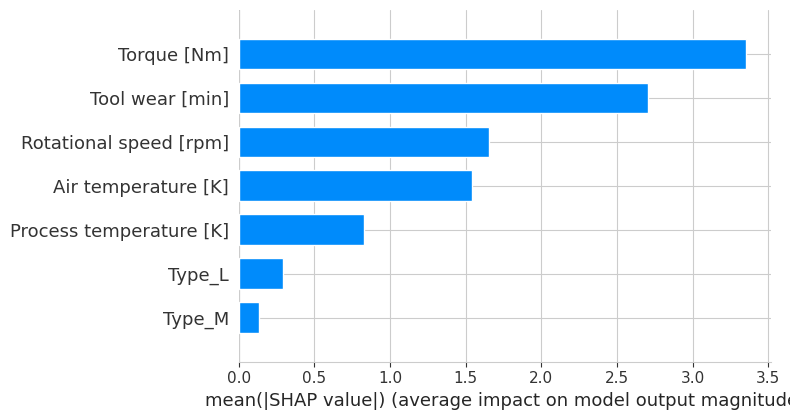


=== GLOBAL: Beeswarm — importance + direction of effect ===


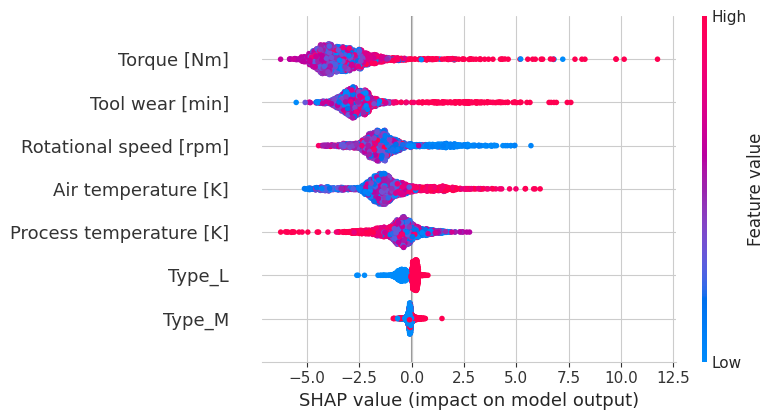

In [ ]:
print('--- STEP 10: SHAP EXPLAINABILITY — STAGE 1 (XGBoost) ---')

import shap

# TreeExplainer
explainer_stage1 = shap.TreeExplainer(best_xgb_binary_model)

# Compute SHAP values for the FULL test set
shap_values_stage1 = explainer_stage1(X_bi_test_scaled_noSMOTE)
shap_values_stage1.feature_names = X_bi_test.columns.tolist()

print(f"SHAP values shape: {shap_values_stage1.shape}")
print(f"Baseline (expected value): {explainer_stage1.expected_value:.4f}")
print("This is the model's average predicted log-odds across the training data —")
print("the starting point before any feature pushes the prediction up or down.\n")

# ---- GLOBAL EXPLANATION ----
print("=== GLOBAL: Feature importance across all test machines ===")
shap.summary_plot(shap_values_stage1, X_bi_test, plot_type="bar", show=True)

# The beeswarm plot is richer: shows not just importance, but WHICH DIRECTION each
# feature pushes (high value = red, low value = blue) and how spread out the effect is
print("\n=== GLOBAL: Beeswarm — importance + direction of effect ===")
shap.summary_plot(shap_values_stage1, X_bi_test, show=True)

--- LOCAL EXPLANATION: One specific flagged machine ---
Explaining Machine (test set row index): 21
Actual failure type(s): {'TWF': 0, 'HDF': 0, 'PWF': 1, 'OSF': 0}


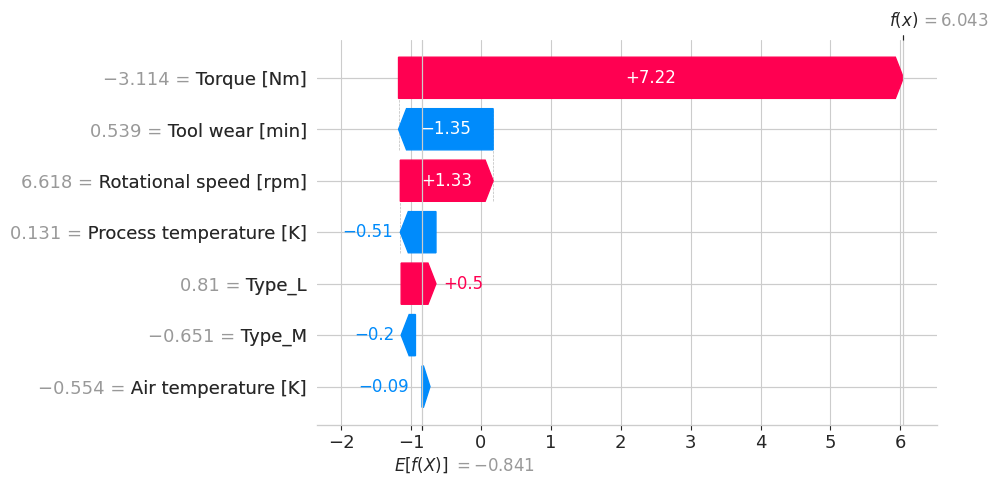

In [ ]:
print('--- LOCAL EXPLANATION: One specific flagged machine ---')

# Pick the first true-positive flagged machine from your cascade results
example_idx_in_flagged = np.where(true_positive_mask)[0][0]
example_global_idx = flagged_idx[example_idx_in_flagged]

print(f"Explaining Machine (test set row index): {example_global_idx}")
print(f"Actual failure type(s): {y_true_multi_flagged.iloc[example_idx_in_flagged].to_dict()}")

# Waterfall plot: shows exactly how THIS machine's SHAP values sum to its prediction
shap.plots.waterfall(shap_values_stage1[example_global_idx], show=True)

--- Explaining Machine (test row 40) ---
Raw sensor readings:
Air temperature [K]         302.6
Process temperature [K]     310.4
Rotational speed [rpm]     1359.0
Torque [Nm]                  57.2
Tool wear [min]              67.0
Type_L                        1.0
Type_M                        0.0
Name: 40, dtype: float64



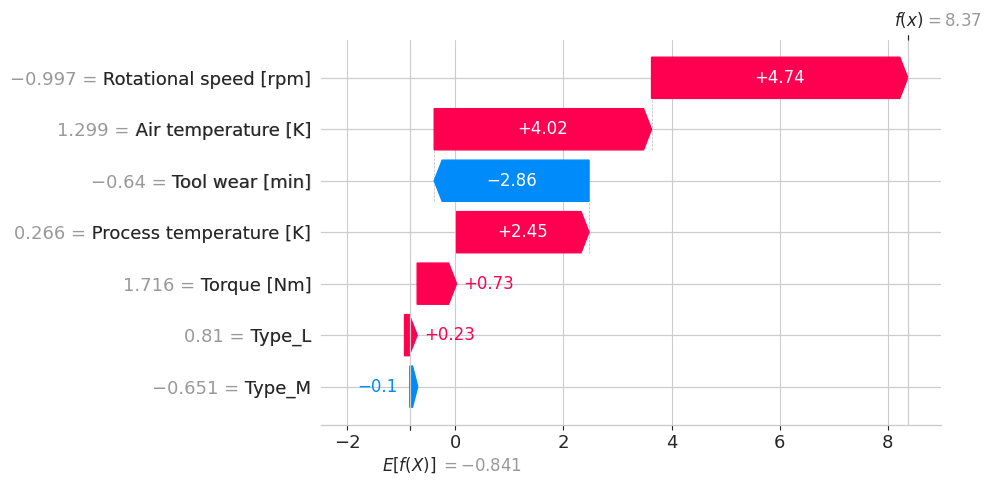

In [ ]:
def explain_machine(row_idx, X_test_original, shap_values, explainer):
    """
    Generate a per-machine SHAP explanation.
    row_idx: index into the test set (original, unscaled row for readability)
    """
    print(f"--- Explaining Machine (test row {row_idx}) ---")
    print(f"Raw sensor readings:\n{X_test_original.iloc[row_idx]}\n")
    shap.plots.waterfall(shap_values[row_idx], show=True)

# Example: explain another flagged machine
explain_machine(flagged_idx[1], X_bi_test.reset_index(drop=True), shap_values_stage1, explainer_stage1)

In [ ]:
print('--- STEP 11: SHAP EXPLAINABILITY — STAGE 2 (Logistic Regression, per failure type) ---')

import shap

# final_stage2_model.estimators_ is a list of 4 LogisticRegression models,
# one per failure type, in the same order as failure_type_names_modeled
stage2_explainers = {}
stage2_shap_values = {}

# Background data for LinearExplainer's baseline (E[x_i] in the formula above) —
# use a sample of the Stage 2 training data, since that's what each model learned from
background_stage2 = shap.sample(X_stage2_train_scaled_final, 100, random_state=42)

for i, failure_type in enumerate(failure_type_names_modeled):
    sub_model = final_stage2_model.estimators_[i]

    explainer = shap.LinearExplainer(sub_model, background_stage2)
    shap_vals = explainer(X_flagged_scaled)  # explain the SAME flagged machines from the cascade

    stage2_explainers[failure_type] = explainer
    stage2_shap_values[failure_type] = shap_vals

    print(f"{failure_type}: baseline (expected value) = {explainer.expected_value:.4f}")

print("\nComputed SHAP values for all 4 failure-type sub-models, on the flagged machines from the cascade.")

--- STEP 11: SHAP EXPLAINABILITY — STAGE 2 (Logistic Regression, per failure type) ---
TWF: baseline (expected value) = -6.4260
HDF: baseline (expected value) = -7.1682
PWF: baseline (expected value) = -2.3674
OSF: baseline (expected value) = -5.7810

Computed SHAP values for all 4 failure-type sub-models, on the flagged machines from the cascade.



=== GLOBAL: What drives HDF classification? ===


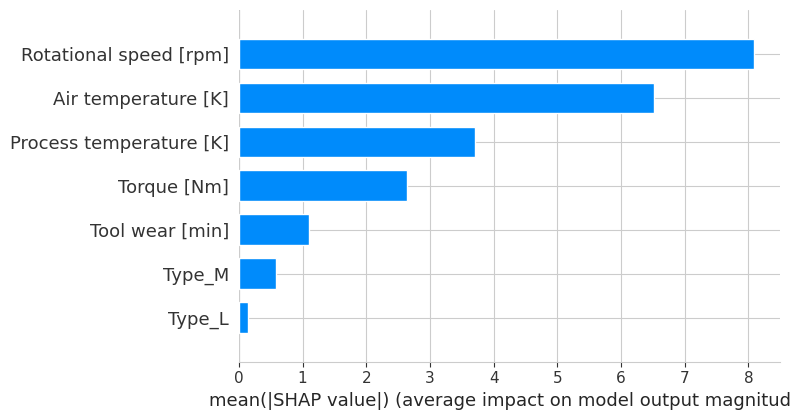

In [ ]:
print("\n=== GLOBAL: What drives HDF classification? ===")
shap.summary_plot(
    stage2_shap_values['HDF'].values,
    pd.DataFrame(X_flagged_scaled, columns=X_bi_test.columns),
    plot_type="bar",
    show=True
)


=== GLOBAL: What drives TWF classification? ===


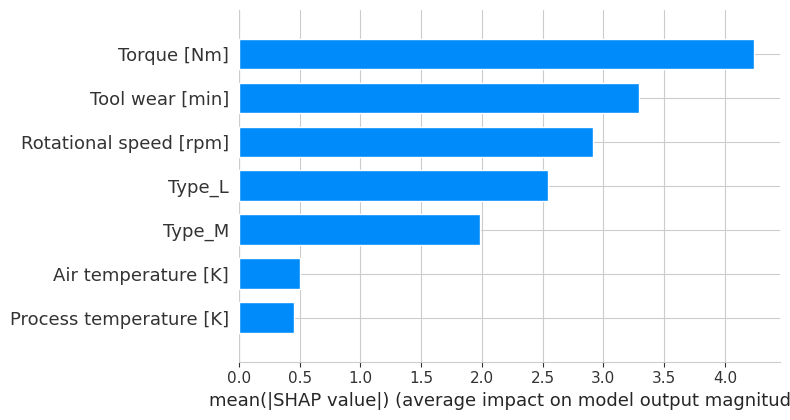


=== GLOBAL: What drives HDF classification? ===


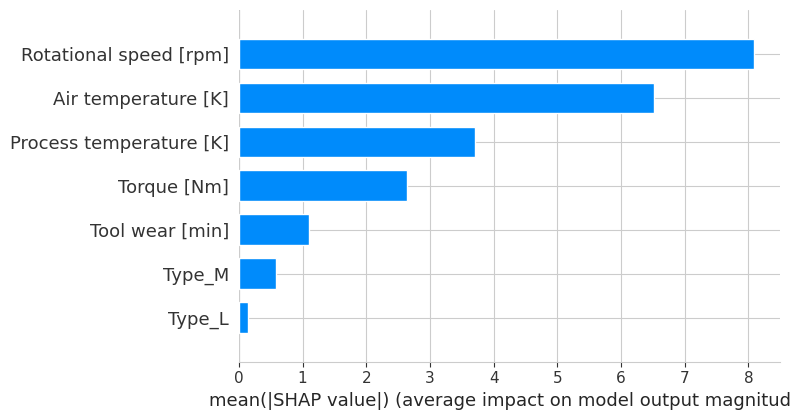


=== GLOBAL: What drives PWF classification? ===


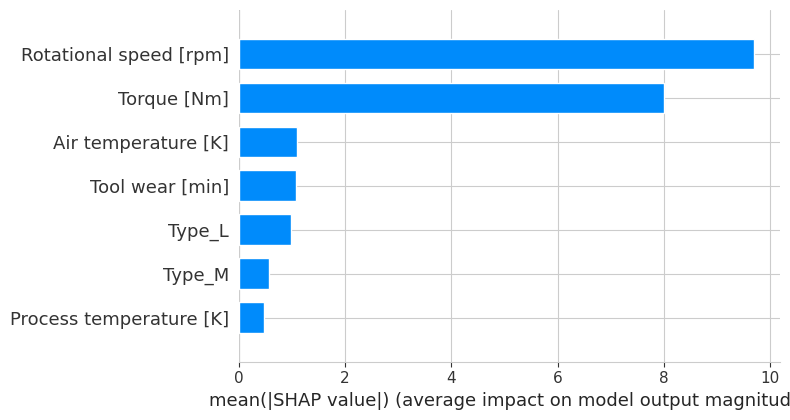


=== GLOBAL: What drives OSF classification? ===


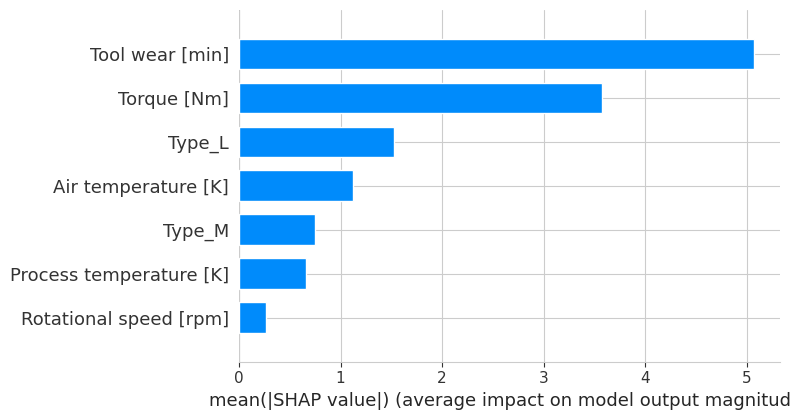

In [ ]:
for failure_type in failure_type_names_modeled:
    print(f"\n=== GLOBAL: What drives {failure_type} classification? ===")
    shap.summary_plot(
        stage2_shap_values[failure_type].values,
        pd.DataFrame(X_flagged_scaled, columns=X_bi_test.columns),
        plot_type="bar",
        show=True
    )

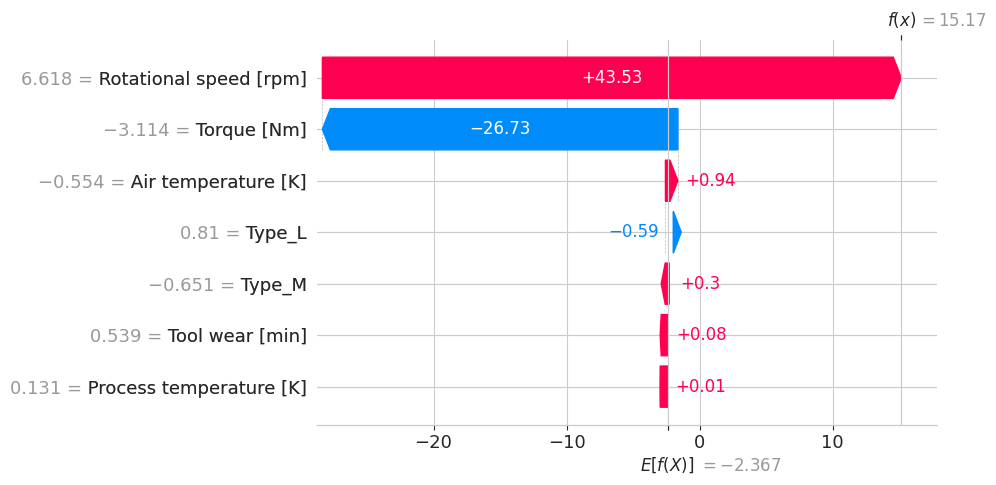

In [ ]:
# Same machine as your first Stage 1 local example (test row 21)
# Find its position within the flagged set
machine_position_in_flagged = np.where(flagged_idx == 21)[0][0]
for failure_type in failure_type_names_modeled:
    stage2_shap_values[failure_type].feature_names = X_bi_test.columns.tolist()

# Run the local plot
shap.plots.waterfall(stage2_shap_values['PWF'][machine_position_in_flagged], show=True)

In [ ]:
print('--- STEP 12a: SHAP MAGNITUDE PER FLAGGED MACHINE ---')

# Stage 1 SHAP magnitude: how strongly, in total, did feature evidence drive
# THIS machine's failure prediction? (sum of |SHAP| across all features)
# shap_values_stage1 was computed on the FULL test set — select just the flagged rows
stage1_shap_magnitude = pd.Series(
    np.abs(shap_values_stage1.values[flagged_idx]).sum(axis=1),
    index=X_bi_test.iloc[flagged_idx].index,
    name='stage1_shap_magnitude'
)

# Stage 2 SHAP magnitude: same idea, but per failure type (4 separate sub-models)
stage2_shap_magnitudes = pd.DataFrame({
    ft: np.abs(stage2_shap_values[ft].values).sum(axis=1)
    for ft in failure_type_names_modeled
}, index=X_bi_test.iloc[flagged_idx].index)

print("Stage 1 SHAP magnitude (flagged machines):")
display(stage1_shap_magnitude.head())
print("\nStage 2 SHAP magnitudes per failure type (flagged machines):")
display(stage2_shap_magnitudes.head())

--- STEP 12a: SHAP MAGNITUDE PER FLAGGED MACHINE ---
Stage 1 SHAP magnitude (flagged machines):


,stage1_shap_magnitude
1391,11.205420
4495,15.132255
8582,16.462769
9664,11.986097
4632,11.729529



Stage 2 SHAP magnitudes per failure type (flagged machines):


,TWF,HDF,PWF,OSF
1391,30.517785,51.297809,72.167871,15.817234
4495,12.435207,16.377301,15.121526,12.168501
8582,19.986186,29.683522,27.599697,14.313566
9664,12.144606,14.713854,14.759990,11.558235
4632,15.780552,20.660689,15.661906,12.157228


In [ ]:
print('--- STEP 12: Ranking/Scheduling  ---')

# 1. Retrieve Stage 1 Failure Probabilities
# stage1_failure_probabilities
stage1_failure_probabilities = pd.Series(
    best_xgb_binary_model.predict_proba(X_bi_test_scaled_noSMOTE)[:, 1],
    index=X_bi_test.index,
    name='failure_probability'
)

# Filter for flagged machines
flagged_machines_mask = stage1_failure_probabilities >= 0.5
stage1_failure_probabilities_flagged = stage1_failure_probabilities[flagged_machines_mask]

print("Stage 1 Failure Probabilities for flagged machines:")
display(stage1_failure_probabilities_flagged.head())


--- STEP 12: Ranking/Scheduling  ---
Stage 1 Failure Probabilities for flagged machines:


,failure_probability
1391,0.997631
4495,0.999768
8582,0.998443
9664,0.999772
4632,0.840364


In [ ]:
stage2_shap_magnitudes = pd.DataFrame({
    ft: np.abs(stage2_shap_values[ft].values).sum(axis=1) for ft in failure_type_names_modeled
}, index=X_bi_test.iloc[flagged_idx].index)

print("Calculated absolute SHAP magnitudes for Stage 2 failure types.")

Calculated absolute SHAP magnitudes for Stage 2 failure types.


In [ ]:
# 2. Calculate Overall Stage 2 SHAP Magnitude
# stage2_shap_magnitudes already contains magnitudes per failure type for flagged machines
stage2_overall_shap_magnitude = stage2_shap_magnitudes.mean(axis=1)

print("Overall Stage 2 SHAP Magnitude for flagged machines:")
display(stage2_overall_shap_magnitude.head())


Overall Stage 2 SHAP Magnitude for flagged machines:


,0
1391,42.450175
4495,14.025634
8582,22.895743
9664,13.294171
4632,16.065094


In [ ]:
# 2b. Calculate Stage 2 Failure Confidences (Probabilities for each type)
stage2_failure_confidences = pd.DataFrame({
    ft: final_stage2_model.estimators_[i].predict_proba(X_flagged_scaled)[:, 1]
    for i, ft in enumerate(failure_type_names_modeled)
}, index=X_bi_test.iloc[flagged_idx].index)

print("Stage 2 Failure Confidences for flagged machines:")
display(stage2_failure_confidences.head())

Stage 2 Failure Confidences for flagged machines:


,TWF,HDF,PWF,OSF
1391,0.003722,3.893101e-18,1.000000,2.062433e-07
4495,0.000003,9.820638e-01,0.043282,1.537458e-05
8582,0.000008,3.076991e-05,0.998970,6.569392e-01
9664,0.213569,2.312006e-04,0.000615,9.896073e-01
4632,0.073316,5.800169e-01,0.000349,1.565784e-01


In [ ]:
print('1. Calculate Stage 1 SHAP Magnitude')
# Filter shap_values_stage1 to include only the flagged indices
stage1_shap_values_flagged = shap_values_stage1[flagged_idx]
# Calculate the sum of absolute SHAP values for each flagged instance
stage1_shap_magnitude = pd.Series(
    np.abs(stage1_shap_values_flagged.values).sum(axis=1),
    index=X_bi_test.iloc[flagged_idx].index,
    name='stage1_shap_magnitude'
)

print("Stage 1 SHAP Magnitude for flagged machines:")
display(stage1_shap_magnitude.head())

1. Calculate Stage 1 SHAP Magnitude
Stage 1 SHAP Magnitude for flagged machines:


,stage1_shap_magnitude
1391,11.205420
4495,15.132255
8582,16.462769
9664,11.986097
4632,11.729529


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Combine all scores into a single DataFrame
combined_scores = pd.DataFrame({
    'stage1_prob': stage1_failure_probabilities_flagged,
    'stage2_confidence_sum': stage2_failure_confidences.sum(axis=1), # Sum of confidences for all modeled failure types
    'stage1_shap_magnitude': stage1_shap_magnitude,
    'stage2_overall_shap_magnitude': stage2_overall_shap_magnitude
})

# Calculate total SHAP magnitude (Stage 1 + overall Stage 2)
combined_scores['total_shap_magnitude'] = combined_scores['stage1_shap_magnitude'] + combined_scores['stage2_overall_shap_magnitude']

# Normalize all components to a 0-1 scale
scaler = MinMaxScaler()
combined_scores_scaled = pd.DataFrame(
    scaler.fit_transform(combined_scores),
    columns=combined_scores.columns,
    index=combined_scores.index
)

print("Combined and Scaled Scores for Flagged Machines:")
display(combined_scores_scaled.head())


Combined and Scaled Scores for Flagged Machines:


,stage1_prob,stage2_confidence_sum,stage1_shap_magnitude,stage2_overall_shap_magnitude,total_shap_magnitude
1391,0.995210,0.450230,0.480268,0.862927,0.848947
4495,0.999606,0.464723,0.824190,0.126458,0.262625
8582,0.996881,0.887005,0.940720,0.356279,0.506764
9664,0.999613,0.584365,0.548642,0.107506,0.169819
4632,0.671854,0.320675,0.526171,0.179300,0.229997


In [ ]:
# Define weights for each component
w1 = 0.4 # Weight for Stage 1 Probability
w2 = 0.3 # Weight for Sum of Stage 2 Confidences
w3 = 0.3 # Weight for Total SHAP Magnitude

# Calculate the combined priority score
combined_scores_scaled['priority_score'] = (
    w1 * combined_scores_scaled['stage1_prob'] +
    w2 * combined_scores_scaled['stage2_confidence_sum'] +
    w3 * combined_scores_scaled['total_shap_magnitude']
)

print("Combined Scores with Priority Score:")
display(combined_scores_scaled.sort_values(by='priority_score', ascending=False).head())


Combined Scores with Priority Score:


,stage1_prob,stage2_confidence_sum,stage1_shap_magnitude,stage2_overall_shap_magnitude,total_shap_magnitude,priority_score
7997,0.976168,0.455860,0.798753,0.932233,1.000000,0.827225
8582,0.996881,0.887005,0.940720,0.356279,0.506764,0.816883
1391,0.995210,0.450230,0.480268,0.862927,0.848947,0.787837
380,0.975968,0.448834,0.534033,0.854962,0.856281,0.781922
5399,0.960589,1.000000,0.610243,0.194614,0.267118,0.764371


### Rank Machines and Apply Resource Constraint
Now, we can rank the machines by their `priority_score` and select the top `N` machines that require immediate attention, based on available maintenance slots.

In [ ]:
# Set the number of available maintenance slots
N_MAINTENANCE_SLOTS = 5 # @param {type:"integer"}

# Rank machines by priority score in descending order
ranked_machines = combined_scores_scaled.sort_values(by='priority_score', ascending=False)

# Get the top N machines for maintenance
top_n_machines_for_maintenance = ranked_machines.head(N_MAINTENANCE_SLOTS)

print(f"\nTop {N_MAINTENANCE_SLOTS} machines recommended for maintenance:")
display(top_n_machines_for_maintenance)



Top 5 machines recommended for maintenance:


,stage1_prob,stage2_confidence_sum,stage1_shap_magnitude,stage2_overall_shap_magnitude,total_shap_magnitude,priority_score
7997,0.976168,0.455860,0.798753,0.932233,1.000000,0.827225
8582,0.996881,0.887005,0.940720,0.356279,0.506764,0.816883
1391,0.995210,0.450230,0.480268,0.862927,0.848947,0.787837
380,0.975968,0.448834,0.534033,0.854962,0.856281,0.781922
5399,0.960589,1.000000,0.610243,0.194614,0.267118,0.764371


In [ ]:
print('--- STEP 13: SAVE THE FULL PIPELINE ---')

import joblib  # standard library for saving/loading sklearn & xgboost objects to disk

# 1. Stage 1 model (XGBoost, tuned, scale_pos_weight-based)
joblib.dump(best_xgb_binary_model, 'stage1_xgb_model.joblib')

# 2. Stage 2 model (Logistic Regression, RNF excluded, retrained on final scaling)
joblib.dump(final_stage2_model, 'stage2_lr_model.joblib')

# 3. The scaler — CRITICAL. Without this exact fitted scaler, raw input can't be
# transformed the same way the training data was, and predictions will be garbage.
joblib.dump(scaler_final, 'scaler_final.joblib')

# 4. Metadata — column order and failure type names. Necessary because a new input
# row (e.g., a dict from a web form) needs to be arranged in the EXACT same column
# order the model was trained on, or the model will silently misread which number
# belongs to which feature.
pipeline_metadata = {
    'feature_columns': X_bi_test.columns.tolist(),        # exact training column order
    'failure_type_names': failure_type_names_modeled       # ['TWF', 'HDF', 'PWF', 'OSF']
}
joblib.dump(pipeline_metadata, 'pipeline_metadata.joblib')

print("Saved: stage1_xgb_model.joblib, stage2_lr_model.joblib, scaler_final.joblib, pipeline_metadata.joblib")

--- STEP 13: SAVE THE FULL PIPELINE ---
Saved: stage1_xgb_model.joblib, stage2_lr_model.joblib, scaler_final.joblib, pipeline_metadata.joblib


In [ ]:
print('--- STEP 13b: SAVE SHAP BACKGROUND DATA ---')
import joblib

# background_stage2 was already created in Step 11 — just persist it
joblib.dump(background_stage2, 'shap_background_stage2.joblib')
print("Saved: shap_background_stage2.joblib")

--- STEP 13b: SAVE SHAP BACKGROUND DATA ---
Saved: shap_background_stage2.joblib


In [ ]:
print('\n--- STEP 14: LOAD PIPELINE + PREDICT ON NEW INPUT ---')

import joblib
import pandas as pd
import numpy as np

# Load everything back — in a fresh script/session this is all you'd need,
# you would NOT need to retrain anything
stage1_model = joblib.load('stage1_xgb_model.joblib')
stage2_model = joblib.load('stage2_lr_model.joblib')
scaler = joblib.load('scaler_final.joblib')
metadata = joblib.load('pipeline_metadata.joblib')

feature_columns = metadata['feature_columns']
failure_type_names = metadata['failure_type_names']


def predict_machine(sensor_readings: dict):
    """
    Takes ONE machine's raw sensor readings as a dictionary and runs it through
    the full cascade: Stage 1 (failure?) -> Stage 2 (what type, if flagged).

    sensor_readings example:
    {
        'Air temperature [K]': 298.5,
        'Process temperature [K]': 308.6,
        'Rotational speed [rpm]': 1410,
        'Torque [Nm]': 60.1,
        'Tool wear [min]': 120,
        'Type_L': 1,
        'Type_M': 0
    }
    """
    # Build a single-row DataFrame, forcing column order to match training exactly.
    # This is the step that prevents "silent misalignment" bugs — if a column is
    # missing from the input dict, this will raise a clear KeyError immediately,
    # rather than the model quietly using garbage values.
    input_df = pd.DataFrame([sensor_readings])[feature_columns]

    # Scale using the SAME fitted scaler from training — .transform() only, never .fit()
    input_scaled = scaler.transform(input_df)

    # ---- Stage 1: is this machine failing? ----
    stage1_pred = stage1_model.predict(input_scaled)[0]              # 0 or 1
    stage1_prob = stage1_model.predict_proba(input_scaled)[0, 1]     # probability of failure

    result = {
        'stage1_prediction': int(stage1_pred),
        'stage1_failure_probability': round(float(stage1_prob), 4),
        'stage2_prediction': None   # filled in below only if Stage 1 flags it
    }

    # ---- Stage 2: only runs if Stage 1 flagged this machine (matches the real cascade) ----
    if stage1_pred == 1:
        stage2_pred = stage2_model.predict(input_scaled)[0]  # array of 0/1, one per failure type

        stage2_confidences = {
            ft: round(float(stage2_model.estimators_[i].predict_proba(input_scaled)[0, 1]), 4)
            for i, ft in enumerate(failure_type_names)
        }

        predicted_types = [ft for ft, flag in zip(failure_type_names, stage2_pred) if flag == 1]

        result['stage2_prediction'] = {
            'predicted_failure_types': predicted_types if predicted_types else ['Unclassified (possibly RNF)'],
            'confidences': stage2_confidences
        }

    return result


# ---- Example usage ----
example_input = {
    'Air temperature [K]': 298.5,
    'Process temperature [K]': 308.6,
    'Rotational speed [rpm]': 1410,
    'Torque [Nm]': 60.1,
    'Tool wear [min]': 120,
    'Type_L': 1,
    'Type_M': 0
}

output = predict_machine(example_input)
print("Prediction result:")
print(output)


--- STEP 14: LOAD PIPELINE + PREDICT ON NEW INPUT ---
Prediction result:
{'stage1_prediction': 0, 'stage1_failure_probability': 0.1224, 'stage2_prediction': None}


In [ ]:
print('--- STEP 15: BATCH PREDICT + RANK FUNCTION ---')

import joblib
import pandas as pd
import numpy as np
import shap
from sklearn.preprocessing import MinMaxScaler

# ---- Load everything the pipeline needs ----
stage1_model = joblib.load('stage1_xgb_model.joblib')
stage2_model = joblib.load('stage2_lr_model.joblib')
scaler = joblib.load('scaler_final.joblib')
metadata = joblib.load('pipeline_metadata.joblib')
background_stage2 = joblib.load('shap_background_stage2.joblib')

feature_columns = metadata['feature_columns']
failure_type_names = metadata['failure_type_names']

# TreeExplainer needs no background data — it reads the tree structure directly
explainer_stage1 = shap.TreeExplainer(stage1_model)

# LinearExplainer needs the saved background sample to compute its baseline correctly
stage2_explainers = {
    ft: shap.LinearExplainer(stage2_model.estimators_[i], background_stage2)
    for i, ft in enumerate(failure_type_names)
}


def rank_machines(sensor_readings_list: list[dict], n_slots: int = 5,
                   w1: float = 0.4, w2: float = 0.3, w3: float = 0.3):
    """
    Takes N machines' raw sensor readings and returns a prioritized maintenance list.

    sensor_readings_list: list of dicts, one per machine, e.g.
        [{'Air temperature [K]': 298.5, 'Process temperature [K]': 308.6, ...}, {...}, ...]
    n_slots: how many machines can actually be sent for maintenance today
    w1, w2, w3: weights for stage1_prob, stage2_confidence, shap_magnitude
                (must match what you used when designing/validating the formula)

    Returns: (full_results_df, top_n_df)
    """
    # Build one DataFrame for all N machines at once — much faster than looping
    # row-by-row through the model, since XGBoost/sklearn are vectorized internally
    input_df = pd.DataFrame(sensor_readings_list)[feature_columns]
    input_scaled = scaler.transform(input_df)

    # ---- Stage 1 on ALL machines ----
    stage1_probs = stage1_model.predict_proba(input_scaled)[:, 1]
    stage1_preds = (stage1_probs >= 0.5).astype(int)

    # ---- Stage 1 SHAP magnitude for ALL machines (needed for ranking later) ----
    shap_vals_stage1 = explainer_stage1(input_scaled)
    stage1_shap_mag_all = np.abs(shap_vals_stage1.values).sum(axis=1)

    results = []
    for i in range(len(sensor_readings_list)):
        entry = {
            'machine_id': i,
            'stage1_prediction': int(stage1_preds[i]),
            'stage1_prob': float(stage1_probs[i]),
            'stage1_shap_magnitude': float(stage1_shap_mag_all[i]),
        }
        results.append(entry)

    results_df = pd.DataFrame(results)

    # ---- Only flagged machines proceed to Stage 2 — same cascade logic as before ----
    flagged_mask = results_df['stage1_prediction'] == 1
    flagged_positions = np.where(flagged_mask)[0]

    if len(flagged_positions) == 0:
        print("No machines flagged by Stage 1 — nothing to rank.")
        return results_df, pd.DataFrame()

    X_flagged = input_scaled[flagged_positions]

    # Stage 2 confidence per failure type, and SHAP magnitude per failure type
    stage2_confidence_sum = np.zeros(len(flagged_positions))
    stage2_shap_mag_sum = np.zeros(len(flagged_positions))
    predicted_types_list = []

    for i, ft in enumerate(failure_type_names):
        sub_model = stage2_model.estimators_[i]
        probs = sub_model.predict_proba(X_flagged)[:, 1]
        stage2_confidence_sum += probs

        shap_vals = stage2_explainers[ft](X_flagged)
        stage2_shap_mag_sum += np.abs(shap_vals.values).sum(axis=1)

    stage2_overall_shap_magnitude = stage2_shap_mag_sum / len(failure_type_names)

    # Record which specific types were predicted, for display purposes
    stage2_hard_preds = stage2_model.predict(X_flagged)
    for row in stage2_hard_preds:
        types = [ft for ft, flag in zip(failure_type_names, row) if flag == 1]
        predicted_types_list.append(types if types else ['Unclassified (possibly RNF)'])

    # ---- Attach Stage 2 results back onto the flagged rows only ----
    results_df.loc[flagged_positions, 'stage2_confidence_sum'] = stage2_confidence_sum
    results_df.loc[flagged_positions, 'stage2_overall_shap_magnitude'] = stage2_overall_shap_magnitude
    results_df.loc[flagged_positions, 'predicted_failure_types'] = pd.Series(
        predicted_types_list, index=flagged_positions
    ).apply(lambda x: ', '.join(x))

    results_df['total_shap_magnitude'] = (
        results_df['stage1_shap_magnitude'].fillna(0) +
        results_df['stage2_overall_shap_magnitude'].fillna(0)
    )

    # ---- Priority score, computed ONLY over flagged machines ----
    # (ranking non-flagged machines makes no sense — they're not going to maintenance)
    flagged_df = results_df.loc[flagged_mask].copy()

    score_cols = ['stage1_prob', 'stage2_confidence_sum', 'total_shap_magnitude']
    mm_scaler = MinMaxScaler()
    scaled_scores = pd.DataFrame(
        mm_scaler.fit_transform(flagged_df[score_cols].fillna(0)),
        columns=score_cols, index=flagged_df.index
    )
    # NOTE: this scaler is refit on THIS batch every call — priority scores are
    # relative to the current batch of flagged machines, not globally comparable
    # across different calls/days. Same design choice as the original notebook cell.

    flagged_df['priority_score'] = (
        w1 * scaled_scores['stage1_prob'] +
        w2 * scaled_scores['stage2_confidence_sum'] +
        w3 * scaled_scores['total_shap_magnitude']
    )

    ranked = flagged_df.sort_values('priority_score', ascending=False)
    top_n = ranked.head(n_slots)

    return results_df, top_n


# ---- Example usage: 5 machines, only 2 maintenance slots available ----
example_batch = [
    {'Air temperature [K]': 298.5, 'Process temperature [K]': 308.6, 'Rotational speed [rpm]': 1410,
     'Torque [Nm]': 150.1, 'Tool wear [min]': 120, 'Type_L': 1, 'Type_M': 0},
    {'Air temperature [K]': 300.1, 'Process temperature [K]': 310.2, 'Rotational speed [rpm]': 2860,
     'Torque [Nm]': 15.2, 'Tool wear [min]': 200, 'Type_L': 0, 'Type_M': 1},
    {'Air temperature [K]': 296.0, 'Process temperature [K]': 306.5, 'Rotational speed [rpm]': 1500,
     'Torque [Nm]': 40.0, 'Tool wear [min]': 50, 'Type_L': 0, 'Type_M': 0},
    {'Air temperature [K]': 303.8, 'Process temperature [K]': 313.1, 'Rotational speed [rpm]': 1350,
     'Torque [Nm]': 650.0, 'Tool wear [min]': 280, 'Type_L': 1, 'Type_M': 0},
    {'Air temperature [K]': 297.2, 'Process temperature [K]': 307.9, 'Rotational speed [rpm]': 1450,
     'Torque [Nm]': 45.5, 'Tool wear [min]': 190, 'Type_L': 0, 'Type_M': 1},
]

all_results, top_n_results = rank_machines(example_batch, n_slots=2)

print("\nAll machines evaluated:")
display(all_results)

print("\nTop machines recommended for maintenance:")
display(top_n_results)

--- STEP 15: BATCH PREDICT + RANK FUNCTION ---

All machines evaluated:


,machine_id,stage1_prediction,stage1_prob,stage1_shap_magnitude,stage2_confidence_sum,stage2_overall_shap_magnitude,predicted_failure_types,total_shap_magnitude
0,0,1,0.999920,14.862186,2.0,47.775278,"PWF, OSF",62.637465
1,1,0,0.014473,7.411050,NaN,NaN,NaN,7.411050
2,2,0,0.000018,11.968733,NaN,NaN,NaN,11.968733
3,3,1,0.999996,16.426373,2.0,247.758582,"PWF, OSF",264.184954
4,4,0,0.000022,9.878586,NaN,NaN,NaN,9.878586



Top machines recommended for maintenance:


,machine_id,stage1_prediction,stage1_prob,stage1_shap_magnitude,stage2_confidence_sum,stage2_overall_shap_magnitude,predicted_failure_types,total_shap_magnitude,priority_score
3,3,1,0.999996,16.426373,2.0,247.758582,"PWF, OSF",264.184954,1.0
0,0,1,0.999920,14.862186,2.0,47.775278,"PWF, OSF",62.637465,0.0


In [ ]:
import xgboost
print(xgboost.__version__)

3.3.0
